**Loading Datasets**

In [1]:
# install SELFIES python package
!pip install -q selfies

In [2]:
# import required modules
from google.colab import drive
import numpy as np
import csv
import pandas as pd
import selfies as sf

In [5]:
# mount the drive
drive.mount('/content/drive')
model1_dir = "/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Github_Upload/Model_1/283.15K/"

# import the SELFIES alphabet
model1_SELFIES_alphabet = np.load(model1_dir + 'model1_SELFIES_alphabet.npy',allow_pickle='TRUE').item()

# import the SELFIES dataset
with open(model1_dir + "model1_283K_dataset.csv", newline='') as file:
    model1_283K_dataset = pd.read_csv(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**One-Hot Encoding of Molecular Physical Structure**

In [6]:
# one-hot encoding
def OneHot(selfies):
    label, one_hot = sf.selfies_to_encoding(
            selfies=selfies,
            vocab_stoi=model1_SELFIES_alphabet,
            pad_to_len=76,
            enc_type = "both")
    return one_hot

for i in range (0,len(model1_283K_dataset.index)):
  model1_283K_dataset['ion1'][i] = OneHot(model1_283K_dataset.iloc[i][1]) + OneHot(model1_283K_dataset.iloc[i][2])

del model1_283K_dataset['ion2']
model1_283K_dataset.rename(columns = {'ion1':'ions'}, inplace = True)

<ipython-input-6-abdf377d133f>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model1_283K_dataset['ion1'][i] = OneHot(model1_283K_dataset.iloc[i][1]) + OneHot(model1_283K_dataset.iloc[i][2])


**Machine Learning Algorithm Setup**

In [7]:
# upload transfer_learning.py
from google.colab import files
files.upload()

Saving transfer_learning.py to transfer_learning.py


{'transfer_learning.py': b'from __future__ import print_function, division\n\nimport torch\nimport torch.nn as nn \nimport torch.optim as optim\nfrom torch.optim import lr_scheduler\nfrom torch.autograd import Variable \n\nimport numpy as np \nimport matplotlib.pyplot as plt \nimport time \nimport os \n\nclass NeuralNet(nn.Module):\n\tdef __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):\n\t\tsuper(NeuralNet, self).__init__()\n\t\tself.fc1 = nn.Linear(input_size, hidden_size_1)\n\t\tself.fc2 = nn.Linear(hidden_size_1, hidden_size_2)\n\t\tself.fc3 = nn.Linear(hidden_size_2, output_size)\n\t\tself.relu = nn.ReLU()\n\n\tdef forward(self, x):\n\t\tout = self.fc1(x)\n\t\tout = self.relu(out)\n\t\tout = self.fc2(out)\n\t\tout = self.relu(out)\n\t\tout = self.fc3(out)\n\t\treturn out '}

In [8]:
from transfer_learning import NeuralNet
import torch
import torch.nn as nn
import torch.optim as optim
import os, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
# index of the top 260 features based on feature-permutation analysis
feature_index = [18, 26, 27, 29, 33, 38, 42, 47, 57, 72, 73, 78, 100, 103, 107, 109, 125, 159, 162, 170, 182, 196, 200, 207, 213, 216, 222, 228, 229, 231, 234, 242, 246, 248, 256, 265, 300, 305, 308, 315, 326, 332, 338, 351, 352, 356, 369, 378, 384, 403, 415, 419, 421, 424, 430, 440, 442, 450, 454, 455, 460, 467, 473, 482, 488, 494, 508, 516, 519, 534, 546, 559, 565, 573, 586, 592, 598, 601, 623, 632, 638, 650, 653, 662, 663, 681, 702, 705, 724, 727, 733, 767, 779, 794, 806, 809, 831, 861, 883, 910, 913, 962, 984, 987, 993, 1002, 1039, 1066, 1079, 1091, 1097, 1106, 1118, 1143, 1149, 1170, 1210, 1222, 1225, 1247, 1262, 1268, 1274, 1287, 1326, 1351, 1372, 1381, 1403, 1476, 1485, 1507, 1528, 1559, 1586, 1641, 1663, 1693, 1715, 3084, 3978, 3990, 3992, 4009, 4024, 4044, 4057, 4077, 4100, 4109, 4117, 4128, 4134, 4141, 4160, 4168, 4170, 4201, 4212, 4220, 4232, 4238, 4250, 4263, 4270, 4285, 4290, 4297, 4302, 4304, 4324, 4328, 4329, 4336, 4342, 4356, 4368, 4376, 4377, 4419, 4425, 4440, 4446, 4453, 4460, 4473, 4474, 4477, 4480, 4492, 4493, 4505, 4516, 4523, 4529, 4532, 4544, 4549, 4550, 4562, 4568, 4575, 4581, 4596, 4602, 4620, 4627, 4633, 4636, 4654, 4672, 4706, 4715, 4724, 4731, 4737, 4740, 4783, 4810, 4828, 4835, 4839, 4841, 4856, 4862, 4887, 4891, 4896, 4914, 4939, 4966, 4977, 4991, 5006, 5018, 5063, 5070, 5102, 5122, 5199, 5226, 5251, 5272, 5278, 5304, 5382, 5434, 5459, 5486, 5538, 5642, 5694, 5746, 5798, 5823, 5850, 5875, 5902, 5927, 5979]

In [18]:
def transfer_learning(transfer=False, nsamples=None, nbatches=None, learning_rate=None, num_epochs=None):
    seeds = np.arange(nbatches)
    Ns = list() 
    scores_test = list()
    scores_train = list()

    for seed in tqdm(seeds):
        data_small = model1_283K_dataset.sample(n=nsamples, random_state=seed).reset_index(drop=True)
        X_small = []
        y_small = []
        for i in range(0,len(data_small.index)):
          X_small.append(data_small['ions'][i])
          y_small.append(data_small['density'][i]/1000)
        for i in range(0,len(X_small)):
          X_small[i] = np.array(X_small[i]).reshape(7904,).astype(np.float32)
          y_small[i] = y_small[i].astype(np.float32)
        
        X_small = np.array(X_small)
        y_small = np.array(y_small)
        
        X_small_filtered =[[]for i in range(nsamples)]
        for i in range (nsamples):
          for j in feature_index:
              X_small_filtered[i].append(X_small[i][j])
        X_small_filtered = np.array(X_small_filtered)
        
        input_size = 260
        hidden_size_1 = 172
        hidden_size_2 = 86
        output_size = 1

        model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
        
        if transfer:
            model.load_state_dict(torch.load('/content/drive/MyDrive/Colab_Notebooks/IL_Manuscript/Colab_Model_Import/density_298.15K_model.ckpt'))
            model.fc1.weight.requires_grad = False
            model.fc1.bias.requires_grad = False
            model.fc2.weight.requires_grad = False
            model.fc2.bias.requires_grad = False

        X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small_filtered, y_small, test_size=0.1, random_state=1)
        X_small_train, X_small_val, y_small_train, y_small_val = train_test_split(X_small_train, y_small_train, test_size=0.2, random_state=1)

        scores_epoch = list()
        N = 0
        train_losses = []

        for epoch in range(num_epochs):
            inputs_tl = torch.from_numpy(X_small_train)
            labels_tl = torch.from_numpy(y_small_train)
            outputs_tl = model(inputs_tl).view(-1,)
            loss = criterion(outputs_tl, labels_tl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss = 0
            running_loss += loss.item()
            train_losses.append(running_loss/len(X_small_train))
            
            N += 1
   
        plt.ylim(0,0.000001)
        plt.plot(train_losses, label='Training Loss')
        plt.xlabel('Epochs', size=15)
        plt.ylabel('MSE Loss', size=15)
        plt.savefig('/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Figures/SI/TL_Loss_Curves/Model1_283.15K_TL.png',dpi=600)
        Ns.append(N)

        score_train = mean_absolute_percentage_error(torch.from_numpy(y_small_train).data.numpy(), model(torch.from_numpy(X_small_train)).view(-1,).data.numpy())     
        scores_train.append(score_train)
        score_test = mean_absolute_percentage_error(torch.from_numpy(y_small_test).data.numpy(), model(torch.from_numpy(X_small_test)).view(-1,).data.numpy())
        scores_test.append(score_test)
    
    return scores_train, scores_test

In [11]:
def Average(score):
    return (sum(score)/len(score))*100

**Direct Learning**

100%|██████████| 100/100 [04:55<00:00,  2.96s/it]


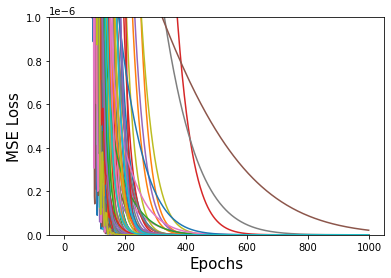

In [12]:
scores_train_wo_transfer, scores_test_wo_transfer = transfer_learning(transfer=False, nsamples=15, nbatches=100, learning_rate=0.0005, num_epochs=1000)

In [13]:
print('The average MAPE of direct learning training set is:', Average(scores_train_wo_transfer),'%')
print('The average MAPE of direct learning testing set is:', Average(scores_test_wo_transfer),'%')

The average MAPE of direct learning training set is: 0.0001744171800135419 %
The average MAPE of direct learning testing set is: 10.032870245631784 %


**Transfer Learning**

100%|██████████| 100/100 [22:29<00:00, 13.49s/it]


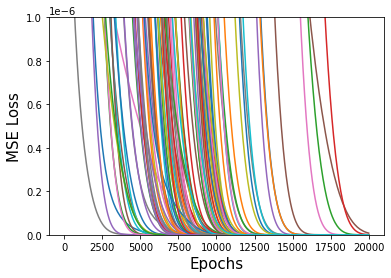

In [19]:
scores_train_w_transfer, scores_test_w_transfer = transfer_learning(transfer=True, nsamples=15, nbatches=100, learning_rate=0.00001, num_epochs=20000)

In [20]:
print('The average MAPE of transfer learning training set is:', Average(scores_train_w_transfer),'%')
print('The average MAPE of transfer learning testing set is:', Average(scores_test_w_transfer),'%')

The average MAPE of transfer learning training set is: 0.0002615186420102944 %
The average MAPE of transfer learning testing set is: 3.1660107840143605 %
